# 对应原文的结果3.7
# Integrated Gene- and Lineage-Level Decisions Resolve AML Branch Pionts

# Application1 of scRL on AML dataset

In [1]:
import scanpy as sc
sc.set_figure_params(dpi=150,fontsize=14,figsize=(5,5))

import warnings
warnings.filterwarnings('ignore')

In [2]:
adata = sc.read_h5ad('F5_AML.h5ad')

## Branch identification 

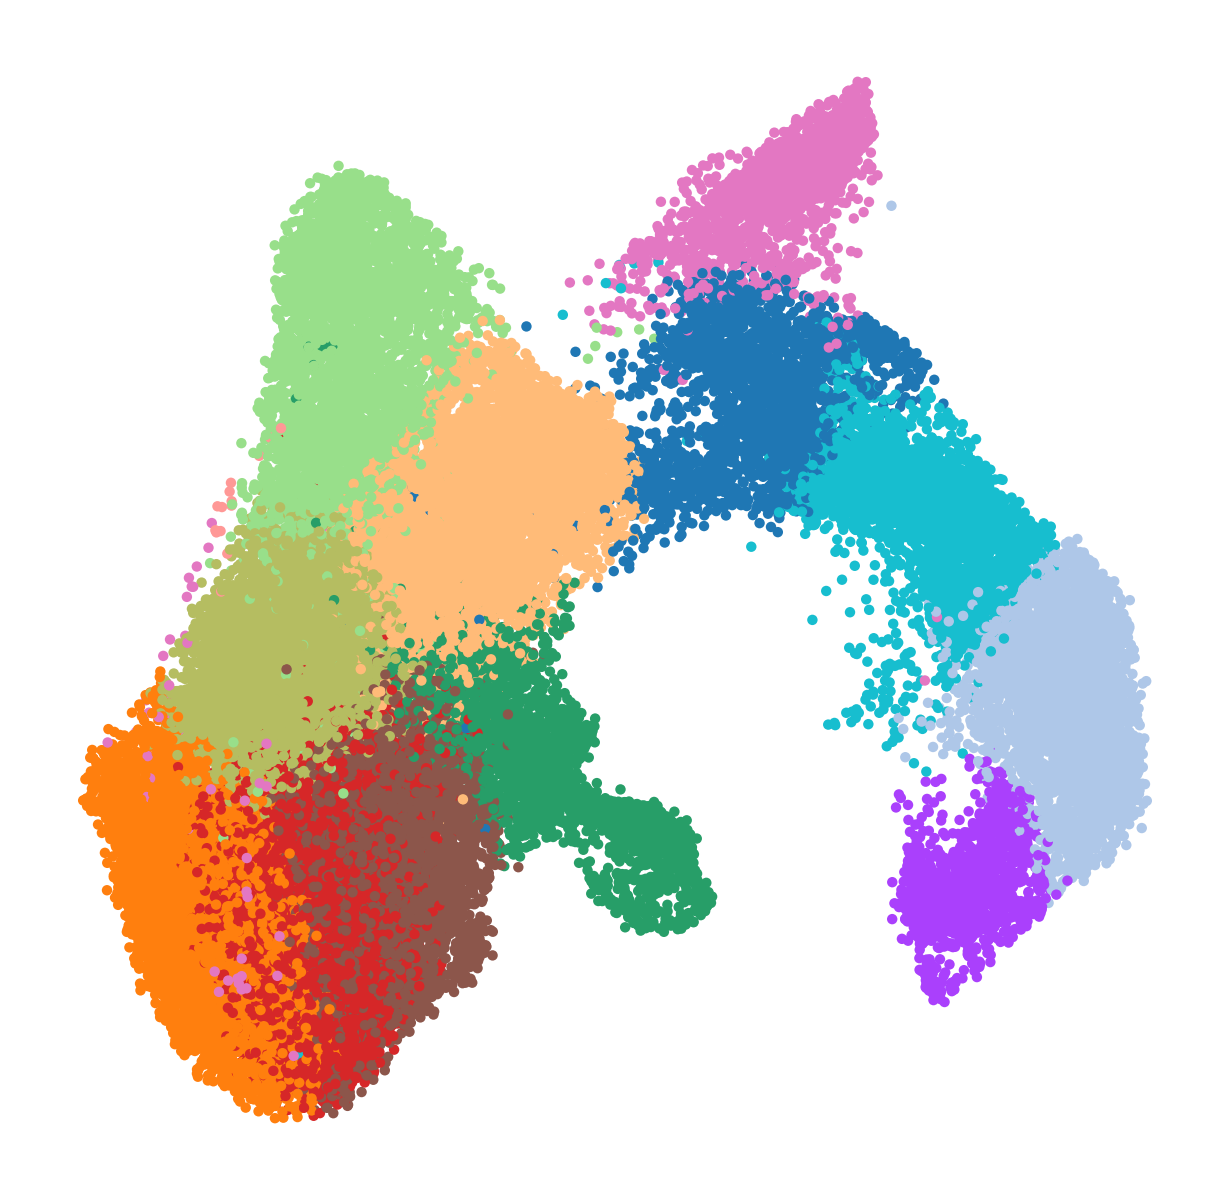

In [3]:
sc.pl.umap(adata, color='leiden',s=25,legend_loc=None, frameon=False,title='')

<AxesSubplot: xlabel='UMAP1', ylabel='UMAP2'>

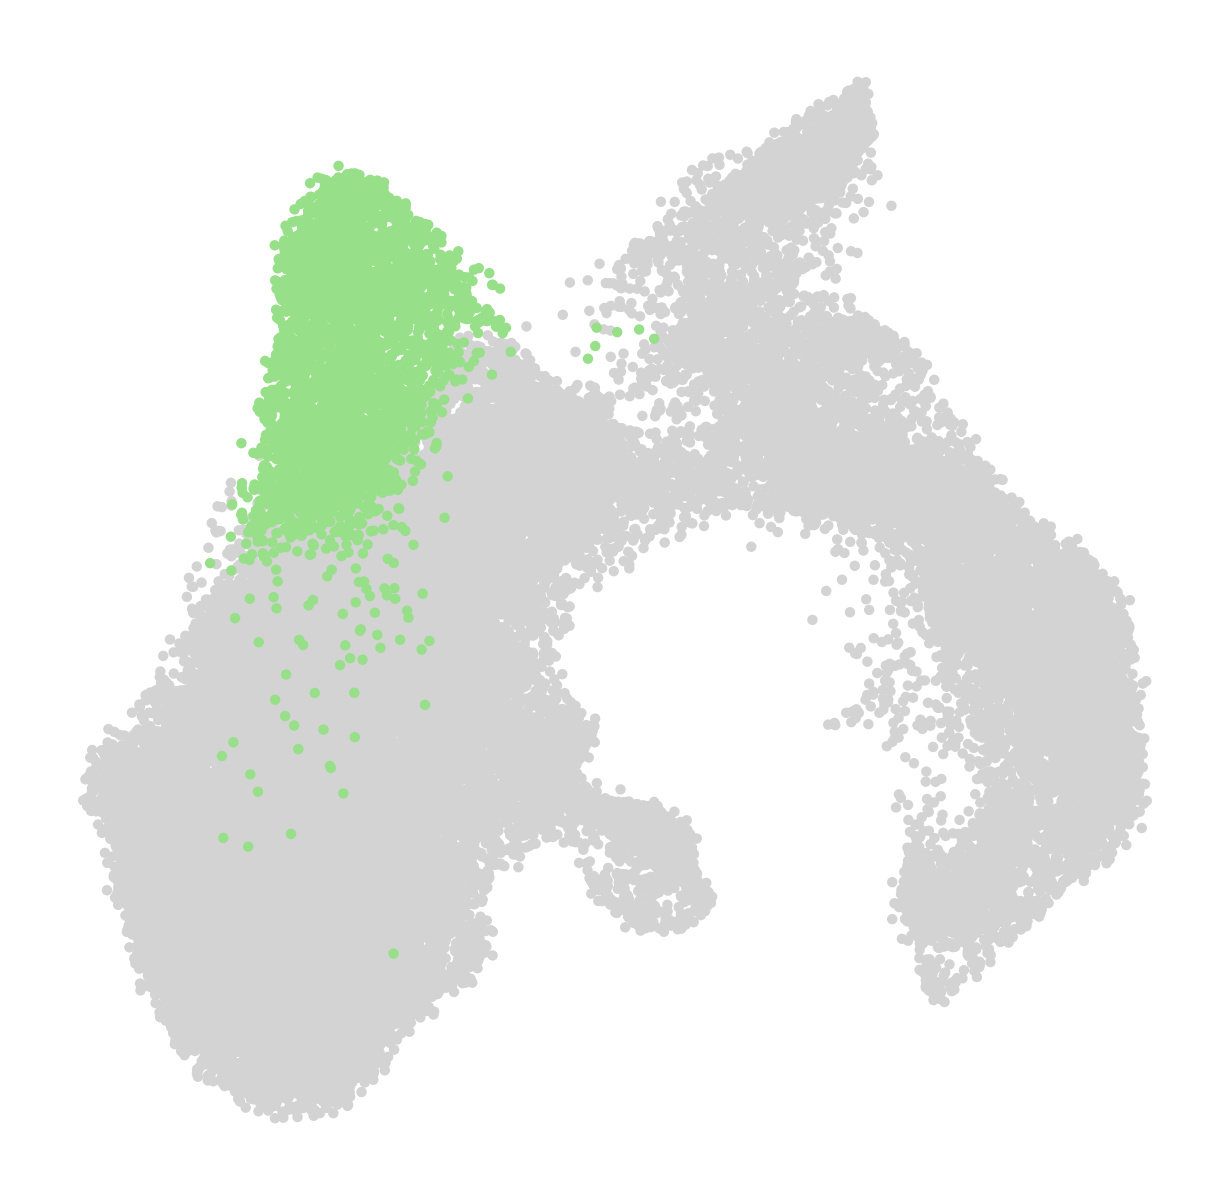

In [4]:
sc.pl.umap(adata, color='leiden', groups=['5'],title='',s=25,frameon=False,legend_loc=None,show=False)

<AxesSubplot: xlabel='UMAP1', ylabel='UMAP2'>

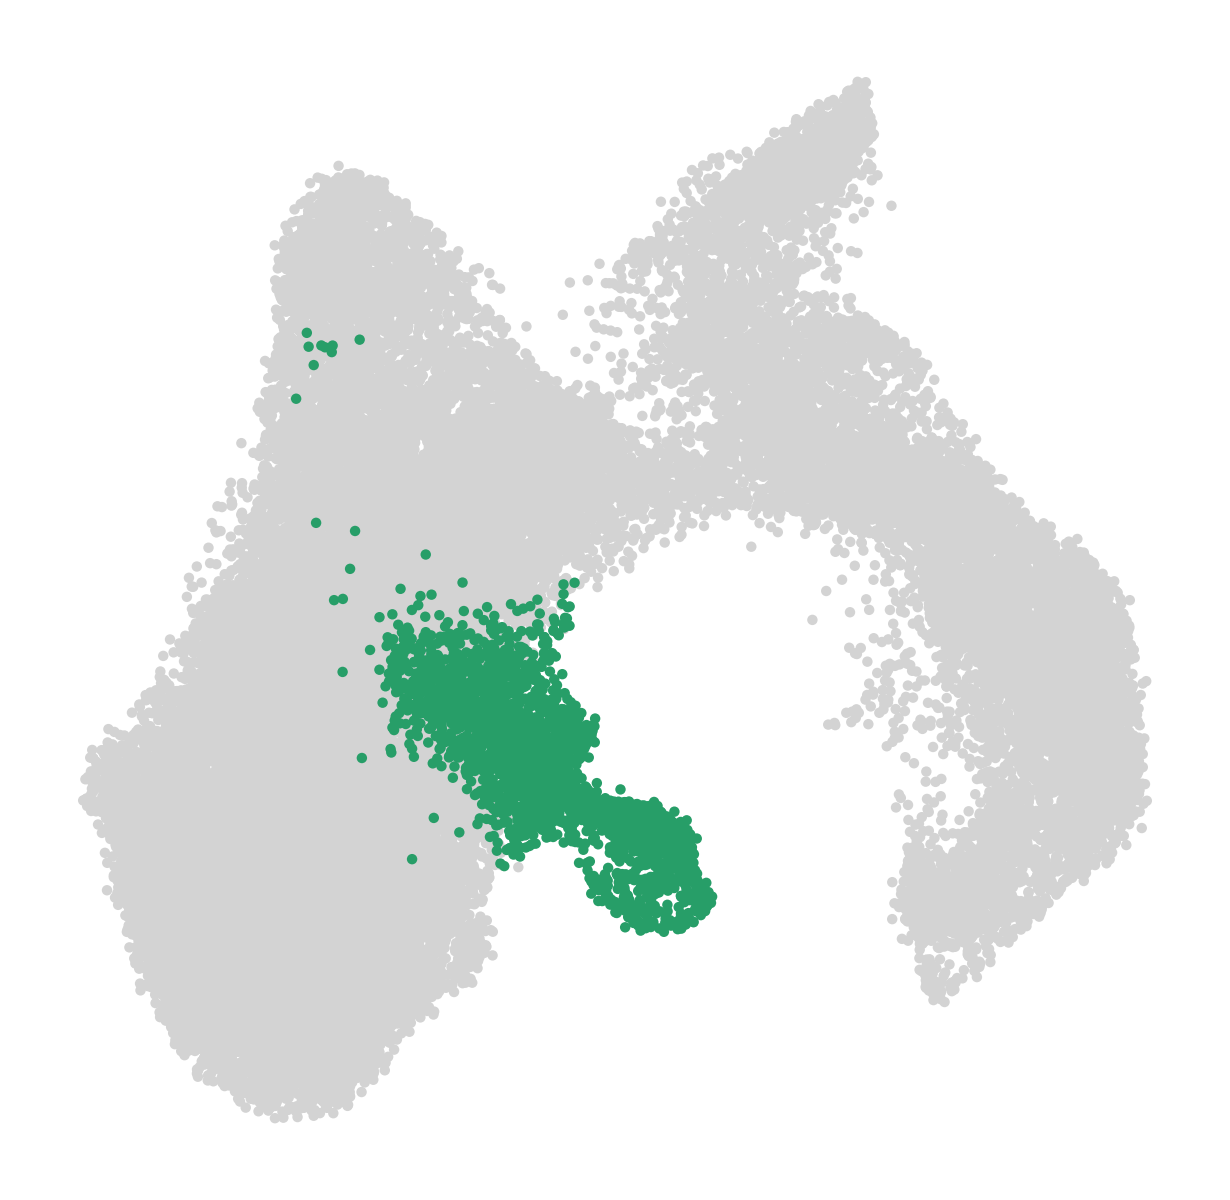

In [5]:
sc.pl.umap(adata, color='leiden', groups=['8'],title='',s=25,frameon=False,legend_loc=None,show=False)

<AxesSubplot: xlabel='UMAP1', ylabel='UMAP2'>

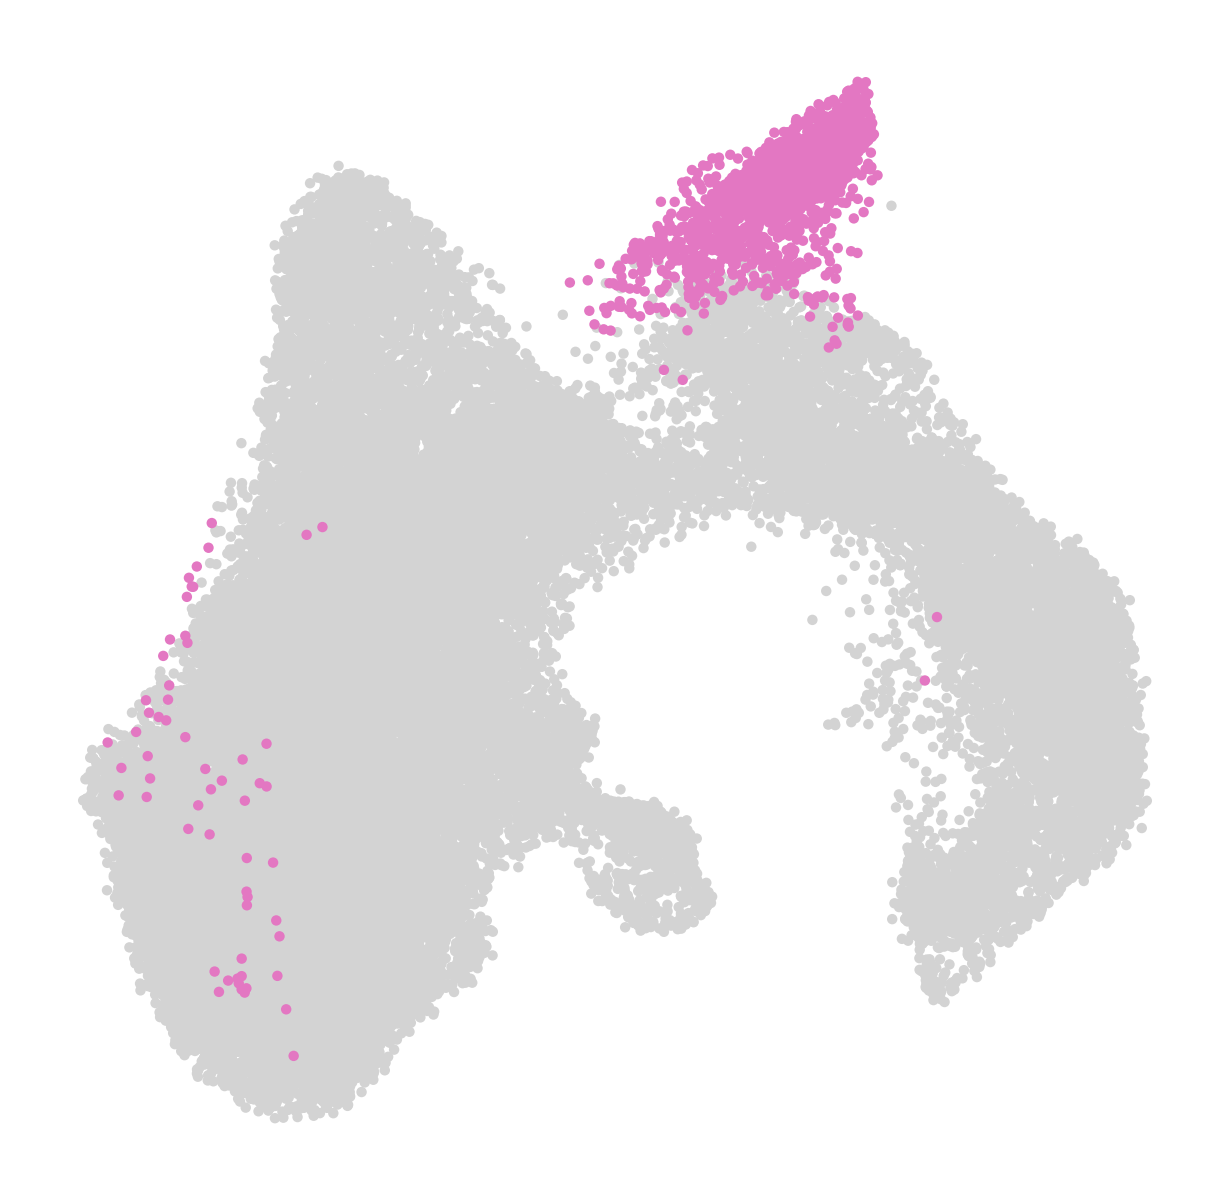

In [6]:
sc.pl.umap(adata, color='leiden', groups=['10'],title='',s=25,frameon=False,legend_loc=None,show=False)

<AxesSubplot: xlabel='UMAP1', ylabel='UMAP2'>

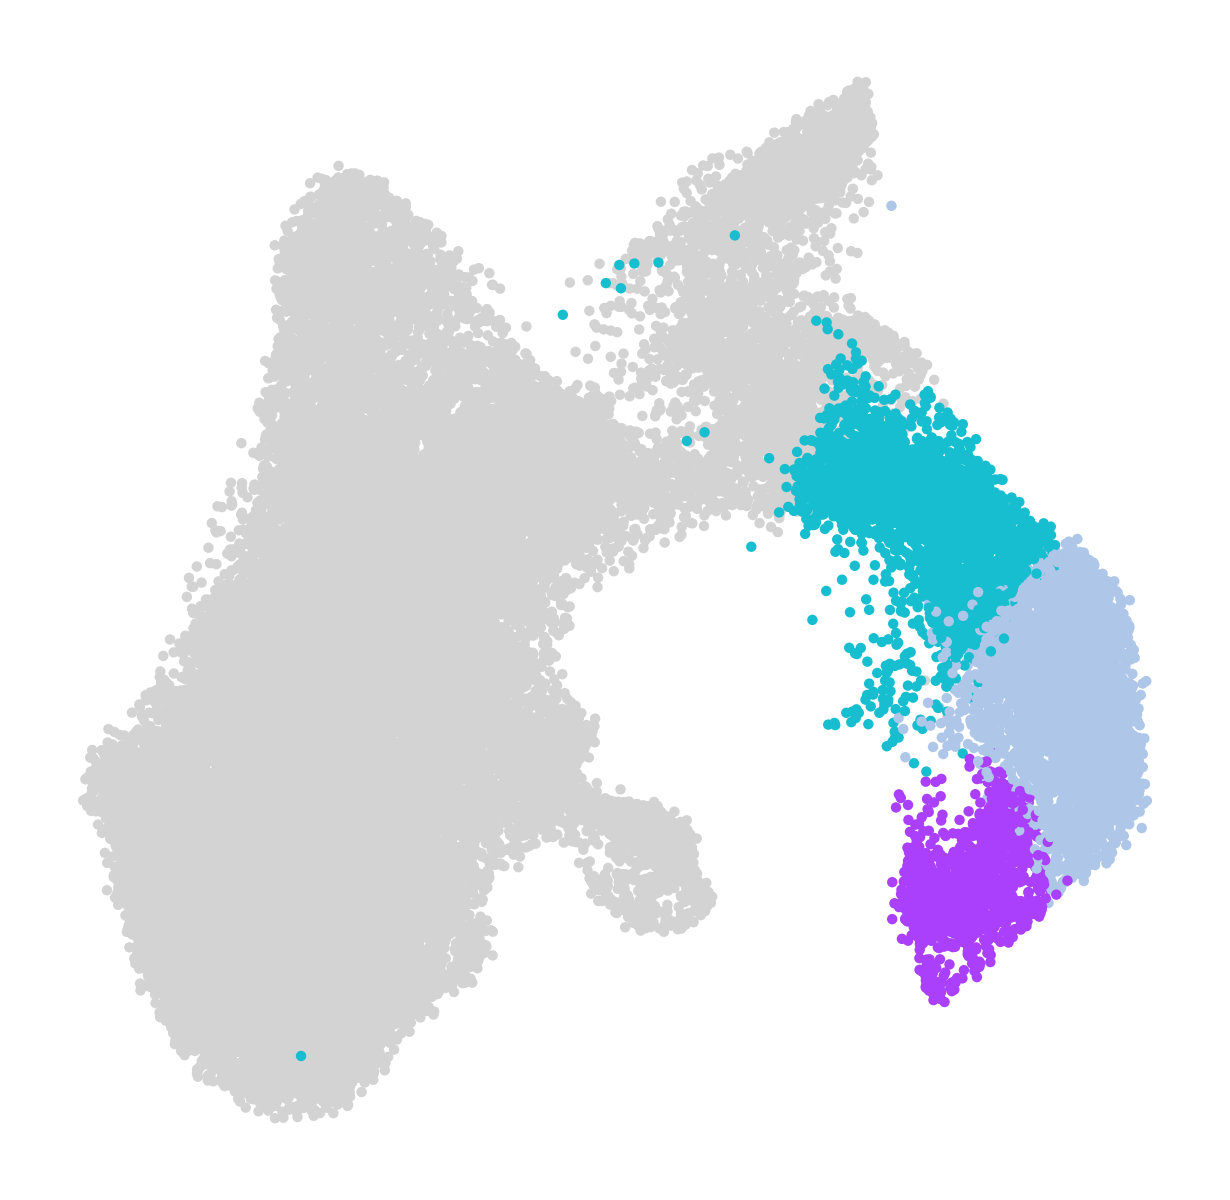

In [7]:
sc.pl.umap(adata, color='leiden', groups=['6','7','11'],title='',s=25,frameon=False,legend_loc=None,show=False)

In [8]:
lut = dict(zip(adata.obs['leiden'].cat.categories, adata.uns['leiden_colors']))

上面只是原本的数据 未作处理  
对应原文的Fig.8 A B C

## Pre-setting information for scRL 

In [9]:
X = adata.obsm['X_umap']
X_pca = adata.obsm['X_pca']
clusters = adata.obs['leiden']
cluster_colors = adata.uns['leiden_colors']

**获取初始化scRL的必要信息：降维，聚类分群**

In [10]:
import scRL

**从原始降维中生成网格嵌入 并将注释信息投射到网格嵌入空间  
选择第 3 组为起点，对齐伪时间。**

In [11]:
gres = scRL.grids_from_embedding(X, j=8)
scRL.project_cluster(gres, clusters, cluster_colors)
scRL.align_pseudotime(gres, '3')
scRL.project_back(gres, 'pseudotime')

Adjacent generating: 100%|████████████████| 1551/1551 [00:00<00:00, 2334.30it/s]


Time used for mapping grids: 13.67 seconds
Time used for projecting annotation : 2.53 seconds
Time used for aligning pseudo-time : 0.60 seconds


In [12]:
adata.obs['time'] = gres.embedding['pseudotime']

**可视化Annotated grid embedding**

<AxesSubplot: xlabel='UMAP1', ylabel='UMAP2'>

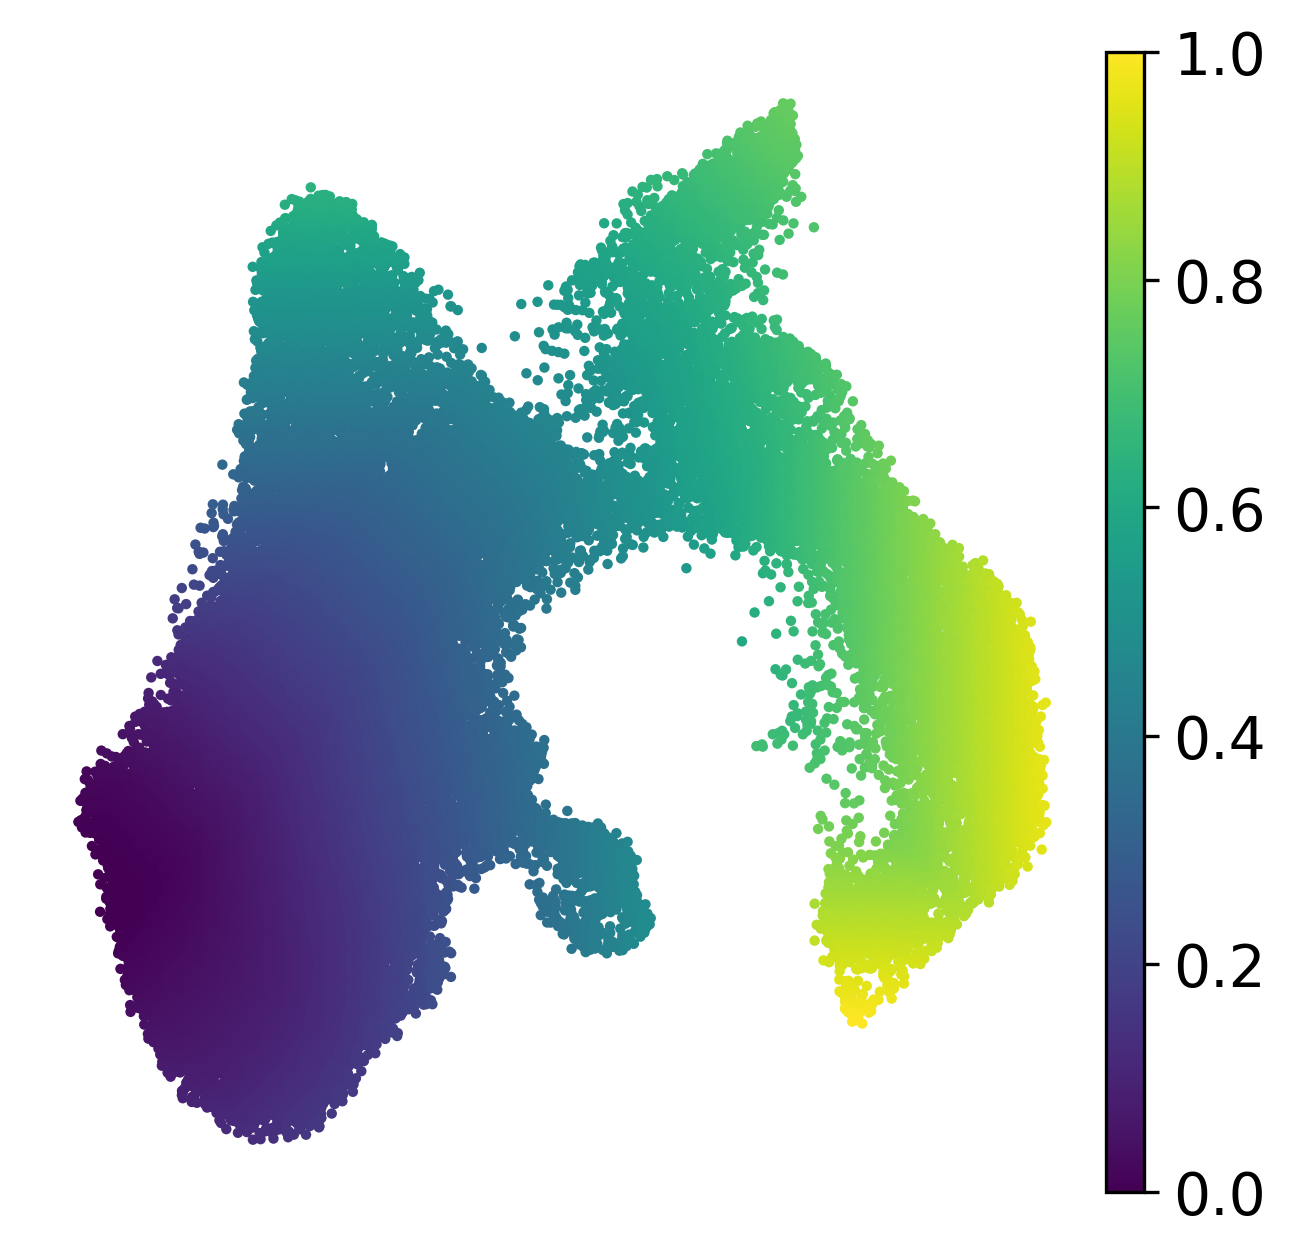

In [13]:
sc.pl.umap(adata, color='time',title='',s=25,frameon=False,show=False)

In [14]:
del adata.uns['log1p']

将Trunk分支注释

In [15]:
adata.obs['branch'] = 'Trunk'
adata.obs['branch'][adata.obs['leiden'].isin(['5'])] = 'Bra1'
adata.obs['branch'][adata.obs['leiden'].isin(['8'])] = 'Bra2'
adata.obs['branch'][adata.obs['leiden'].isin(['10'])] = 'Bra3'
adata.obs['branch'][adata.obs['leiden'].isin(['6','7','9','11'])] = 'Bra4'

对 adata 中按 obs['branch'] 列分组的细胞（如 'Bra1', 'Bra2', ..., 'Bra4'）进行成对差异表达分析。  
每个组 vs 所有其他组（默认方法是 Wilcoxon 秩和检验）。

In [16]:
sc.tl.rank_genes_groups(adata, groupby='branch', pts=True)

 提取并处理每个分支的差异基因结果

In [17]:
rnk1 = sc.get.rank_genes_groups_df(adata, group='Bra1').sort_values('logfoldchanges', ascending=False)
#提取 Bra1 相对于其他所有细胞的差异表达结果。  按 logfoldchanges（log2 fold change）从高到低排序（高表达基因在前）
rnk1['diff'] = rnk1['pct_nz_group'] - rnk1['pct_nz_reference']
#新增一列 diff：表示该基因在 目标组（Bra1）中的非零表达比例 减去 参考组（非 Bra1）中的非零表达比例。
#diff 越大，说明该基因在目标组中更特异表达。
gs1 = rnk1[(rnk1['pct_nz_group'] > .25)&(rnk1['pct_nz_reference']<.25)&(rnk1['diff']>.25)].head(10)['names'].tolist()
#筛选满足以下条件的基因：
#   在目标分支中表达较广（≥25% 细胞表达）；
#   在其他分支中表达稀少（<25% 细胞表达）；
#   表达比例差异显著（差值 > 0.25）。
#取满足条件的前 10 个（按 logFC 排序），提取基因名 → 存为列表 gs1。


rnk2 = sc.get.rank_genes_groups_df(adata, group='Bra2').sort_values('logfoldchanges', ascending=False)

rnk2['diff'] = rnk2['pct_nz_group'] - rnk2['pct_nz_reference']

gs2 = rnk2[(rnk2['pct_nz_group'] > .25)&(rnk2['pct_nz_reference']<.25)&(rnk2['diff']>.25)].head(10)['names'].tolist()



rnk3 = sc.get.rank_genes_groups_df(adata, group='Bra3').sort_values('logfoldchanges', ascending=False)

rnk3['diff'] = rnk3['pct_nz_group'] - rnk3['pct_nz_reference']

gs3 = rnk3[(rnk3['pct_nz_group'] > .25)&(rnk3['pct_nz_reference']<.25)&(rnk3['diff']>.25)].head(10)['names'].tolist()


rnk4 = sc.get.rank_genes_groups_df(adata, group='Bra4').sort_values('logfoldchanges', ascending=False)

rnk4['diff'] = rnk4['pct_nz_group'] - rnk4['pct_nz_reference']

gs4 = rnk4[(rnk4['pct_nz_group'] > .25)&(rnk4['pct_nz_reference']<.25)&(rnk4['diff']>.25)].head(10)['names'].tolist()

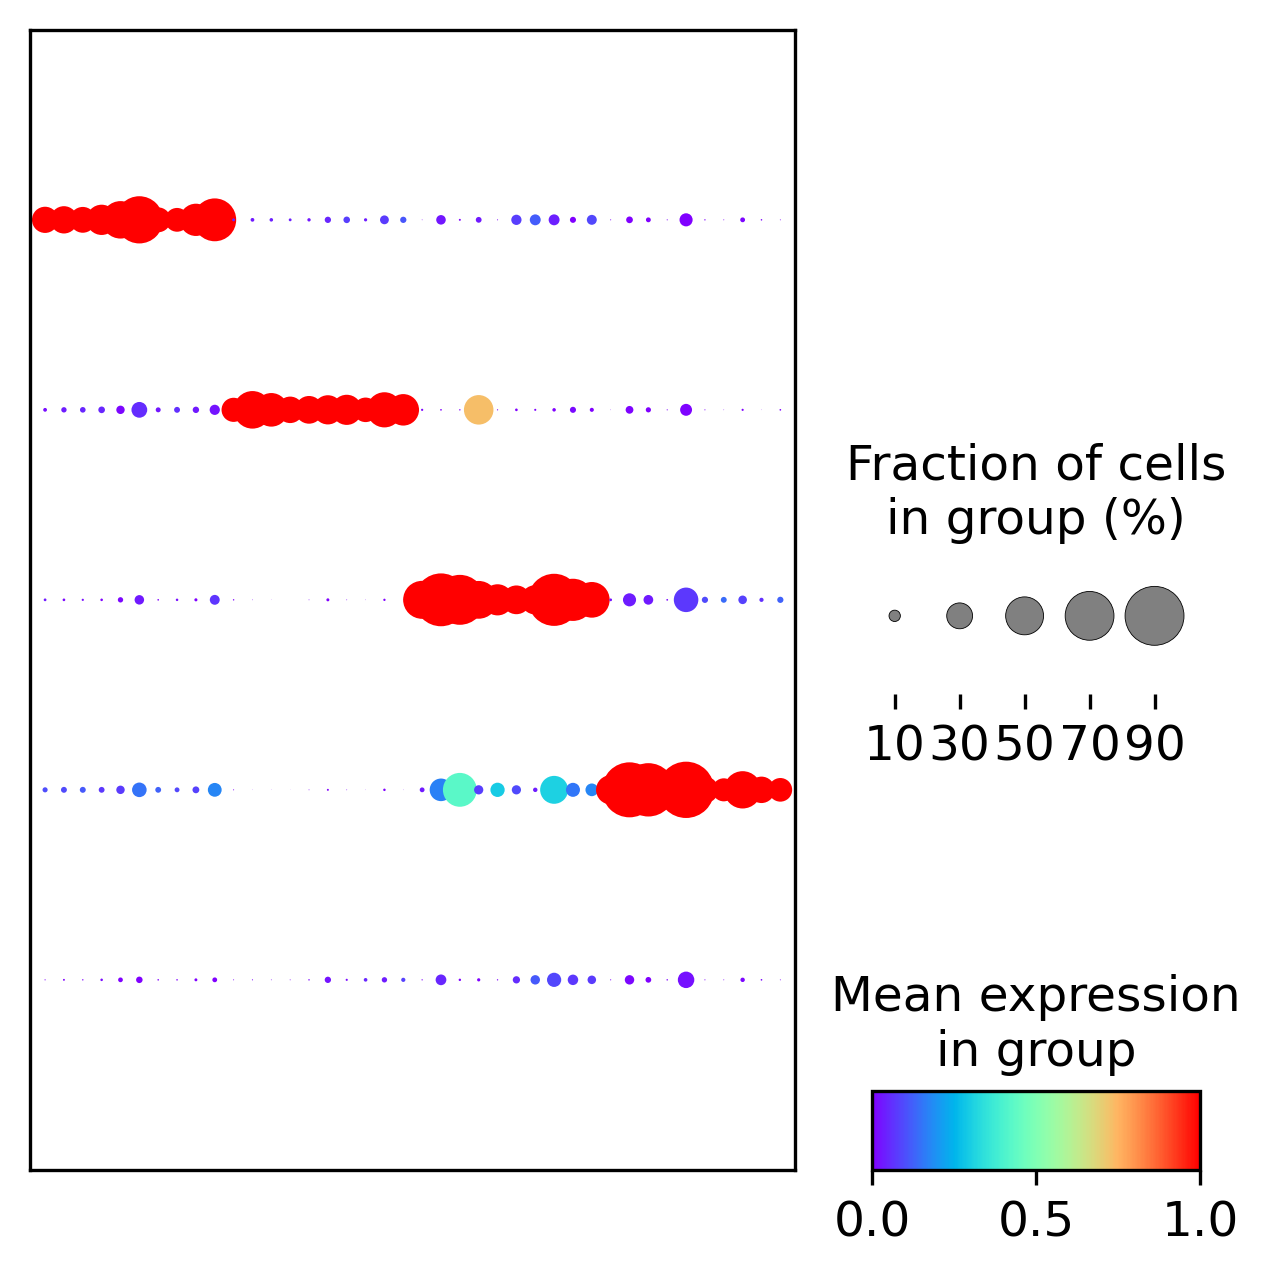

In [18]:
axs = sc.pl.dotplot(adata, var_names=gs1+gs2+gs3+gs4, groupby='branch',cmap='rainbow', standard_scale='var',lw=0, figsize=(5,5),show=False)
axs['mainplot_ax'].tick_params(labelbottom=False,bottom=False,left=False,labelleft=False)

Fig.8 D  
展示每个分支（Bra1–Bra4）是否高表达其“专属”的 marker 基因，从而验证这些基因的分支特异性。   
每一列：代表一个基因（来自 gs1 + gs2 + gs3 + gs4，即四个分支各自筛选出的 top 10 特异基因，共最多 40 个）。  
每一行：代表一个细胞分支（Bra1, Bra2, Bra3, Bra4）。

In [19]:
exp = adata[:,list(set(gs1+gs2+gs3+gs4))].to_df()

In [20]:
scRL.project_expression(gres, exp)

## Gene reward training process 

In [21]:
scRL.gene_rewards(gres, ['1','2','3','4'], gs1)

Reward generating: 100%|██████████████████| 1551/1551 [00:01<00:00, 1467.44it/s]

Time used for reward generation: 1.08 seconds


之前是 Decision reward mode for lineage.  
现在应该是 Decision reward mode for gene set.  

In [23]:
t_gs1 = scRL.trainer('ActorCritic', gres, reward_type='gene', X_latent=X_pca, num_episodes=1e4, gamma=.95)

r, v = t_gs1.train()

Iteration10: 100%|█████████| 1000/1000 [00:17<00:00, 56.46it/s, E=10000, R=7.02]


之前是Fetching the PC space for constructing environment and feed the network  用的是PCA  
现在直接用的是基因矩阵了  作为LDA?
不是的  用的也是PCA 只不过奖励类型只用基因来做

 **Get the fate decision state value of selected gene set  
 获取选定基因集的命运决定状态值 Gene decision value**

In [24]:
scRL.get_state_value(gres, t_gs1, 'gs1')
scRL.project_back(gres, 'gs1')

In [26]:
adata.obs['gs1'] = gres.embedding['gs1']

<AxesSubplot: xlabel='UMAP1', ylabel='UMAP2'>

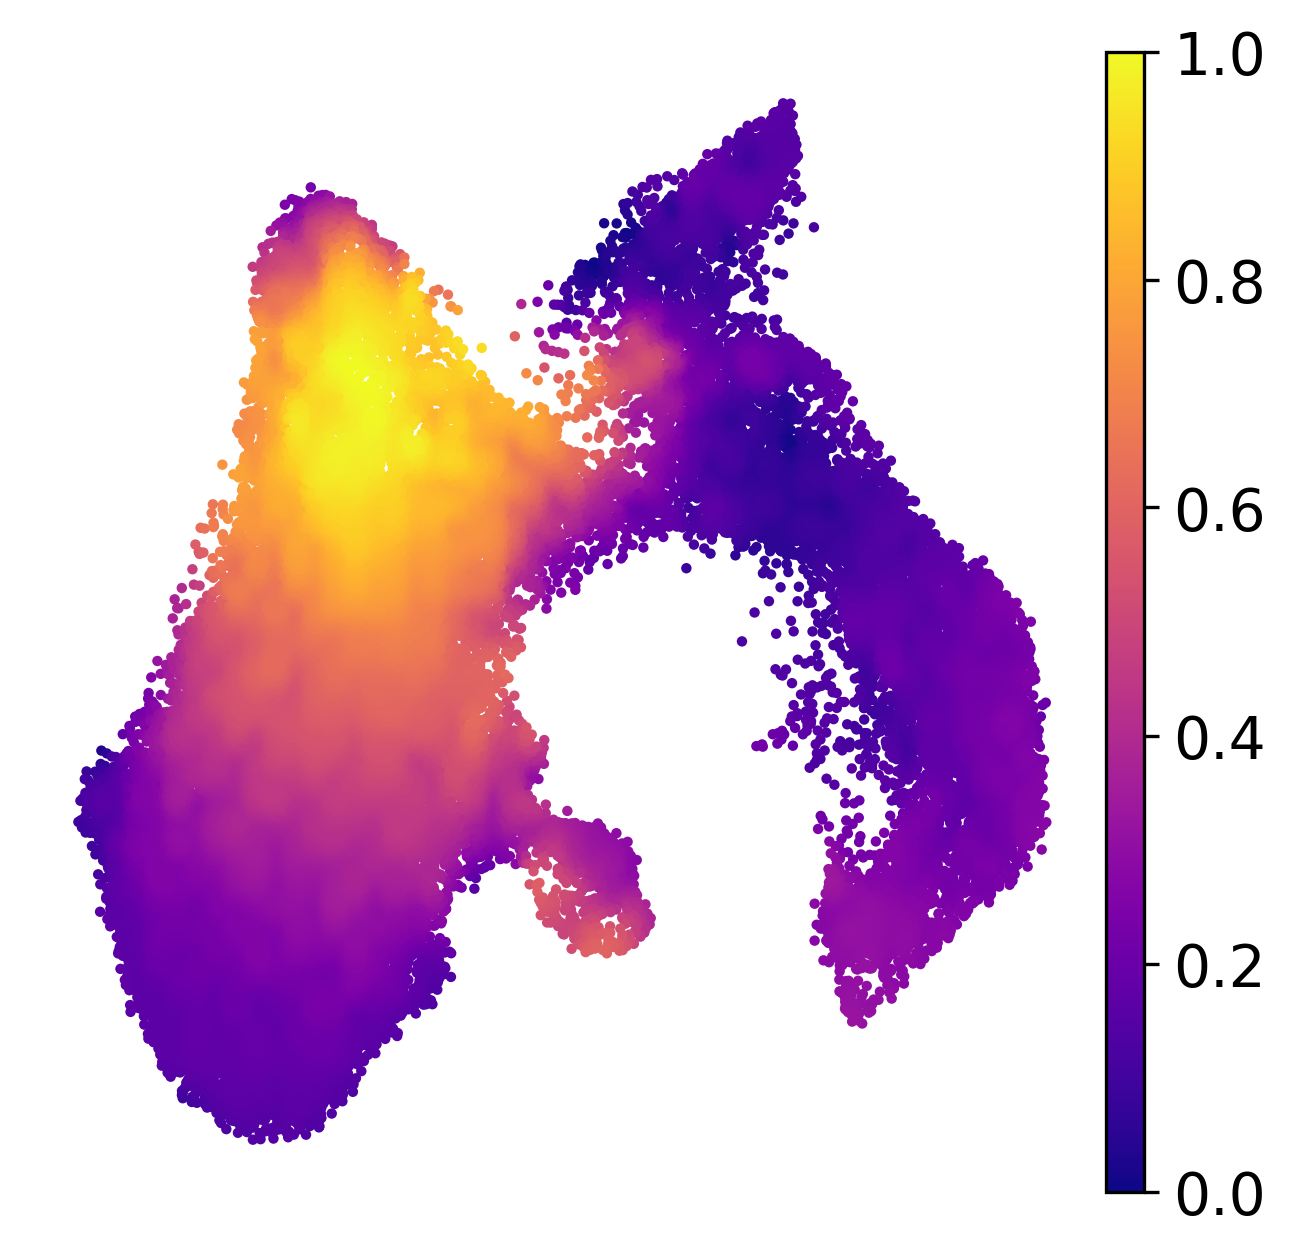

In [27]:
sc.pl.umap(adata, cmap='plasma', color='gs1',s=25,title='',frameon=False,show=False)

In [28]:
scRL.gene_rewards(gres, ['1','2','3','4'], gs2)

Reward generating: 100%|██████████████████| 1551/1551 [00:00<00:00, 1711.96it/s]

Time used for reward generation: 0.92 seconds


In [29]:
t_gs2 = scRL.trainer('ActorCritic', gres, reward_type='gene', X_latent=X_pca, num_episodes=1e4, gamma=.95)

r, v = t_gs2.train()

Iteration10: 100%|█████████| 1000/1000 [00:10<00:00, 93.39it/s, E=10000, R=6.62]


In [30]:
scRL.get_state_value(gres, t_gs2, 'gs2')
scRL.project_back(gres, 'gs2')

In [31]:
adata.obs['gs2'] = gres.embedding['gs2']

<AxesSubplot: xlabel='UMAP1', ylabel='UMAP2'>

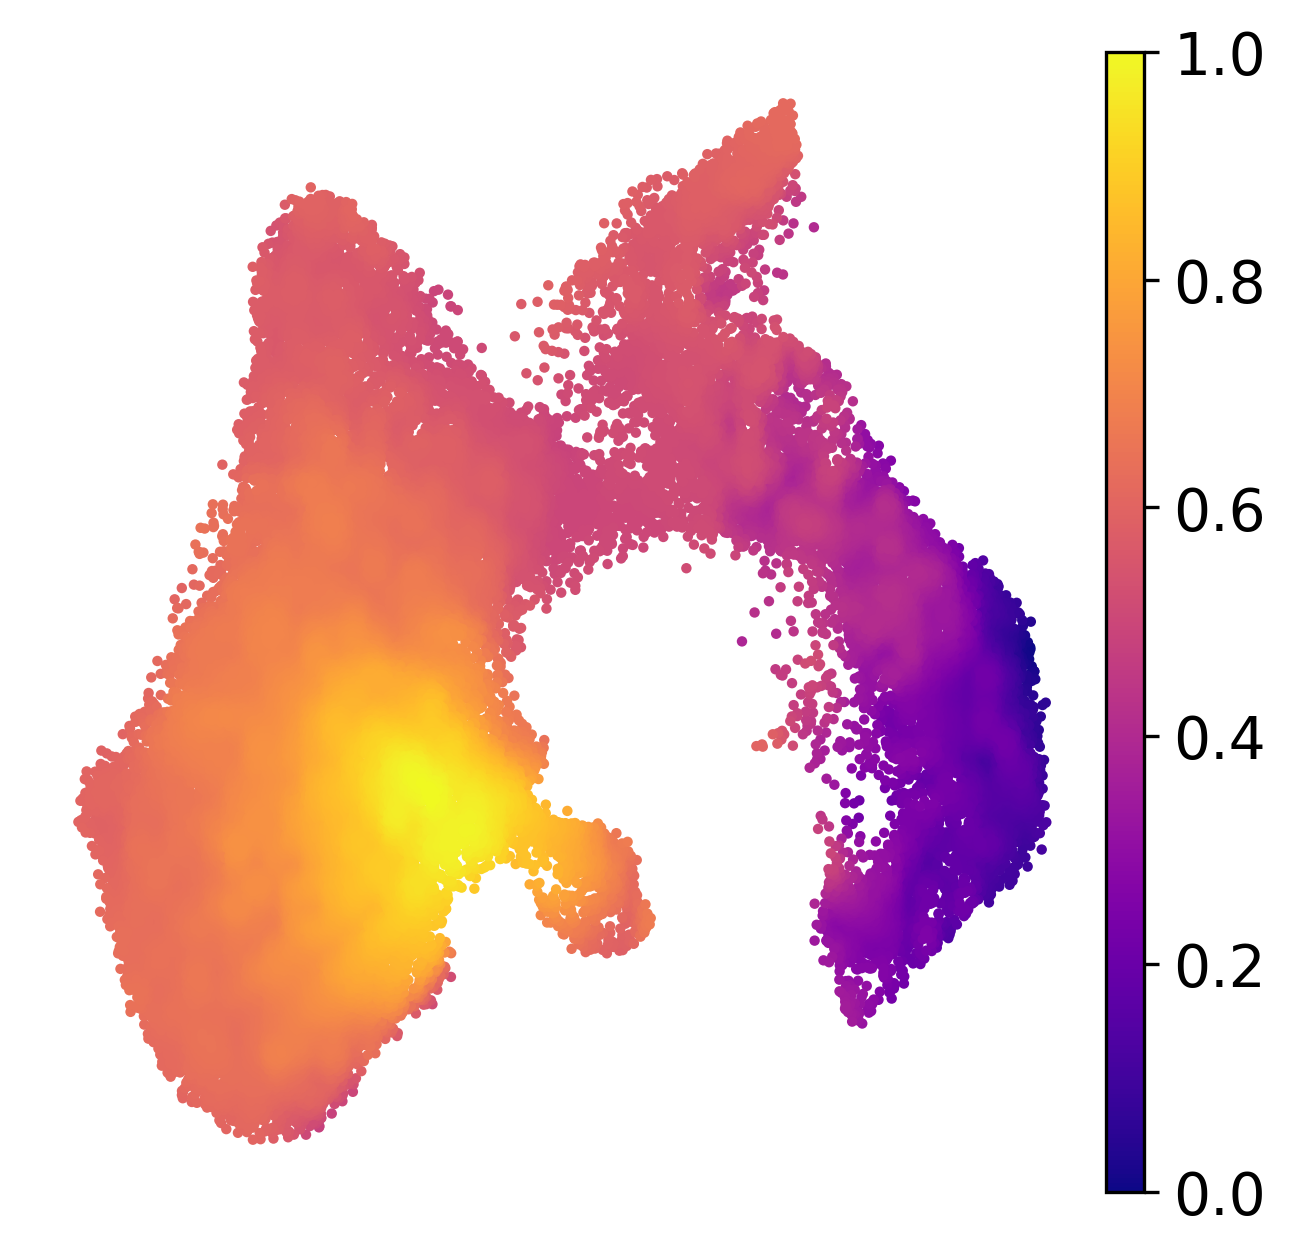

In [32]:
sc.pl.umap(adata, cmap='plasma', color='gs2',s=25,title='',frameon=False,show=False)

In [33]:
scRL.gene_rewards(gres, ['1','2','3','4'], gs3)

Reward generating: 100%|██████████████████| 1551/1551 [00:01<00:00, 1347.62it/s]

Time used for reward generation: 1.17 seconds


In [34]:
t_gs3 = scRL.trainer('ActorCritic', gres, reward_type='gene', X_latent=X_pca, num_episodes=1e4, gamma=.95)

r, v = t_gs3.train()

Iteration10: 100%|█████████| 1000/1000 [00:19<00:00, 52.30it/s, E=10000, R=7.83]


In [35]:
scRL.get_state_value(gres, t_gs3, 'gs3')
scRL.project_back(gres, 'gs3')

In [36]:
adata.obs['gs3'] = gres.embedding['gs3']

<AxesSubplot: xlabel='UMAP1', ylabel='UMAP2'>

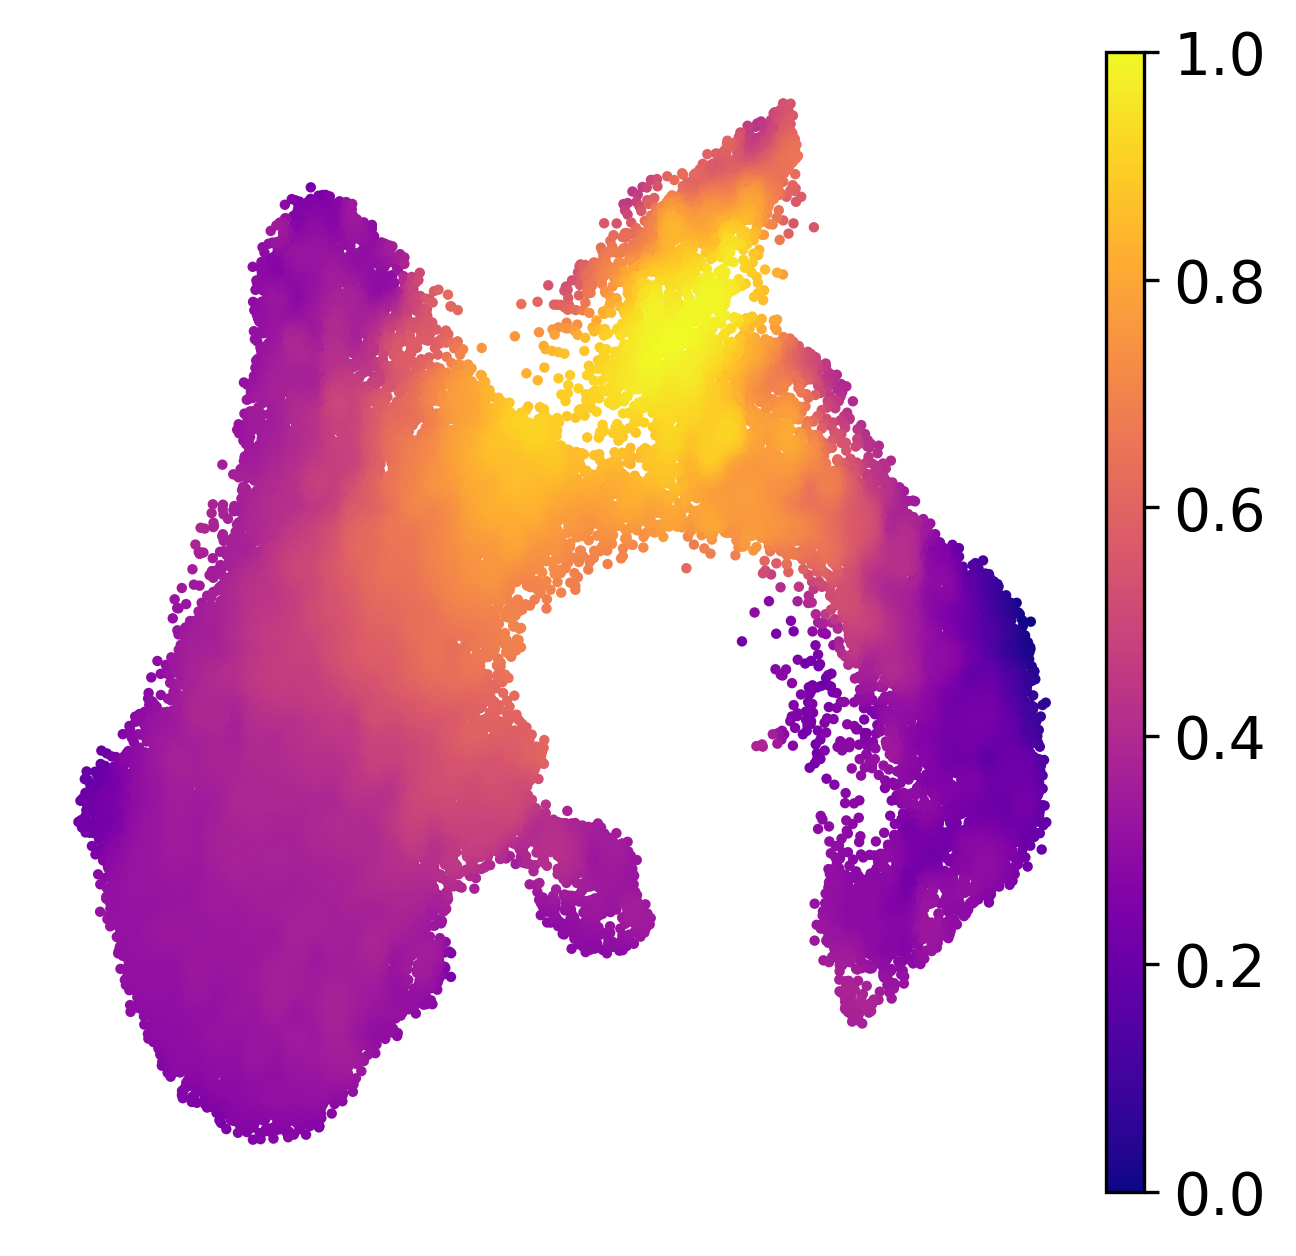

In [37]:
sc.pl.umap(adata, cmap='plasma', color='gs3',s=25,title='',frameon=False,show=False)

In [38]:
scRL.gene_rewards(gres, ['1','2','3','4'], gs4)

Reward generating: 100%|██████████████████| 1551/1551 [00:01<00:00, 1358.70it/s]

Time used for reward generation: 1.16 seconds


In [39]:
t_gs4 = scRL.trainer('ActorCritic', gres, reward_type='gene', X_latent=X_pca, num_episodes=1e4, gamma=.95)

r, v = t_gs4.train()

Iteration10: 100%|████████| 1000/1000 [00:21<00:00, 45.56it/s, E=10000, R=13.51]


In [40]:
scRL.get_state_value(gres, t_gs4, 'gs4')
scRL.project_back(gres, 'gs4')

In [41]:
adata.obs['gs4'] = gres.embedding['gs4']

<AxesSubplot: xlabel='UMAP1', ylabel='UMAP2'>

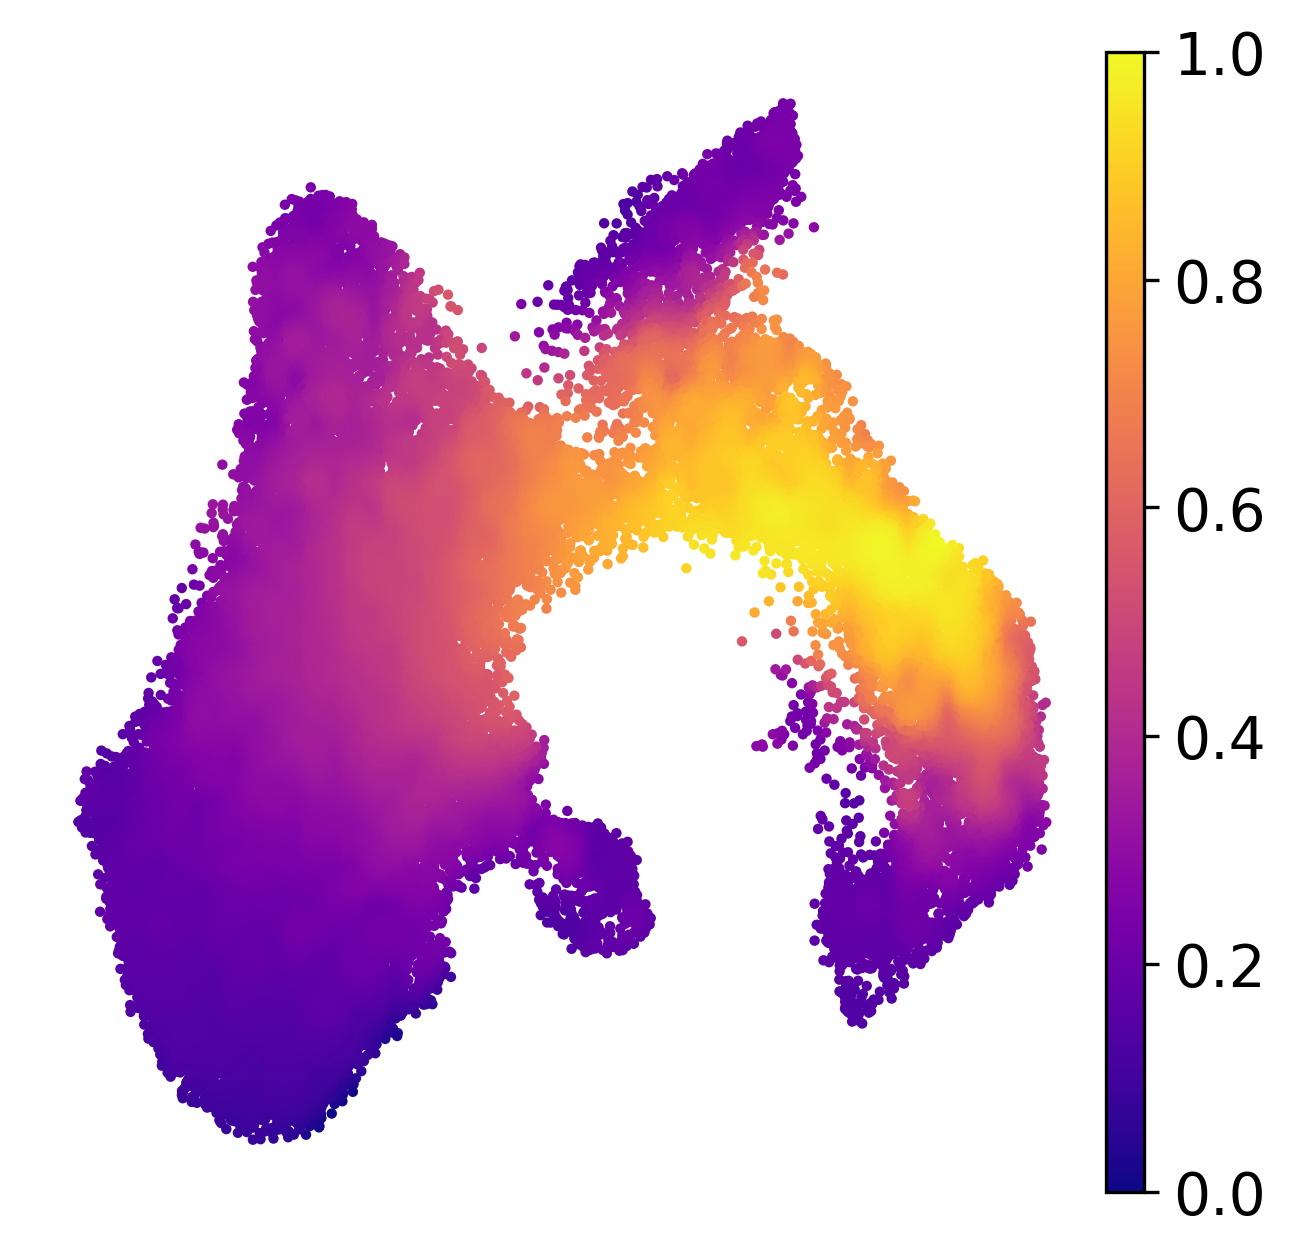

In [42]:
sc.pl.umap(adata, cmap='plasma', color='gs4',s=25,title='',frameon=False,show=False)